In [24]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

In [3]:
path = Path("../data/clean_data.csv")

In [4]:
data = pd.read_csv(path)

In [5]:
data.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalServices,CustomerValue,ContractRisk
0,0,0,1,0,4,0,1,0,0,2,...,0,0,1,2,29.85,29.85,0,1,1,1
1,1,0,0,0,2,1,0,0,2,0,...,0,1,0,3,56.95,1889.50,0,2,2,0
2,1,0,0,0,4,1,0,0,2,2,...,0,0,1,3,53.85,108.15,1,2,1,1


In [6]:
# splitting data into train and test 

x = data.drop("Churn", axis =1)
y = data["Churn"]

In [10]:
x_train , x_test , y_train , y_test = train_test_split(
    x , y , test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
x

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TotalServices,CustomerValue,ContractRisk
0,0,0,1,0,4,0,1,0,0,2,...,0,0,0,1,2,29.85,29.85,1,1,1
1,1,0,0,0,2,1,0,0,2,0,...,0,0,1,0,3,56.95,1889.50,2,2,0
2,1,0,0,0,4,1,0,0,2,2,...,0,0,0,1,3,53.85,108.15,2,1,1
3,1,0,0,0,2,0,1,0,2,0,...,0,0,1,0,0,42.30,1840.75,3,2,0
4,0,0,0,0,4,1,0,1,0,0,...,0,0,0,1,2,70.70,151.65,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,0,1,2,0,2,0,...,2,2,1,1,3,84.80,1990.50,5,2,0
7039,0,0,1,1,1,1,2,1,0,2,...,2,2,1,1,1,103.20,7362.90,4,0,0
7040,0,0,1,1,4,0,1,0,2,0,...,0,0,0,1,2,29.60,346.45,1,1,1
7041,1,1,1,0,4,1,2,1,0,0,...,0,0,0,1,3,74.40,306.60,0,1,1


In [13]:
y.value_counts(normalize=True)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [16]:
sc = StandardScaler()

x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [ ]:
# Creating baseline Model 

In [18]:
lr = LogisticRegression(max_iter=100)

lr.fit(x_train_scaled , y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [20]:
y_pred = lr.predict(x_test_scaled)

In [23]:
report = classification_report(y_test , y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.84      0.90      0.86      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [27]:
y_prob = lr.predict_proba(x_test_scaled)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8339791779689478


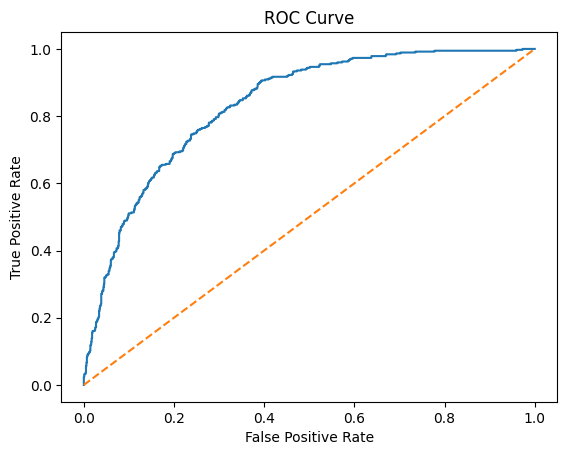

In [28]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [29]:
lr.coef_

array([[ 0.00658691,  0.05716239,  0.00688708, -0.10998439,  0.20540978,
        -0.15674675,  0.13300519,  0.48630302, -0.42130745, -0.31813698,
        -0.2510838 , -0.3934735 , -0.139751  , -0.13667132, -0.64602765,
         0.19128789,  0.1229107 ,  0.52333043, -0.72345629,  0.94357983,
        -0.10146625,  0.04189777]])

In [30]:
dt = DecisionTreeClassifier()

In [31]:
dt.fit(x_train_scaled, y_train)

dt_y_pred = dt.predict(x_test_scaled)

dt_y_pred

array([0, 0, 0, ..., 0, 1, 0], shape=(1409,))

In [32]:
report = classification_report(y_test , dt_y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1035
           1       0.47      0.51      0.49       374

    accuracy                           0.72      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.72      0.72      1409



In [33]:
rf = RandomForestClassifier()

rf.fit(x_train_scaled, y_train)

rf_y_pred = rf.predict(x_test_scaled)

rf_y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

In [34]:
report = classification_report(y_test , rf_y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1035
           1       0.61      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409

